**DataView - Exploração e Análise de Dados de Vendas**
Mini Projeto - Análise de Dados com Python

Importação das Bibliotecas

In [18]:
import pandas as pd
import numpy as np
import random
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

RF01 – Criar ou Carregar o Dataset de Vendas

In [19]:
def gerar_dataset_vendas(n_registros=150, seed=42):
    """Gera um dataset sintético de vendas com dados propositalmente sujos,
       incluindo valores nulos, strings sujas, datas inválidas e outliers.
    """
    random.seed(seed)
    np.random.seed(seed)

    produtos = ["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado", "Mouse"]

    precos = {
        "Notebook": 3500,
        "Smartphone": 2200,
        "Tablet": 1800,
        "Monitor": 1200,
        "Teclado": 250,
        "Mouse": 120
    }

    categorias = {
        "Notebook": "Computadores",
        "Smartphone": "Celulares",
        "Tablet": "Celulares",
        "Monitor": "Computadores",
        "Teclado": "Periféricos",
        "Mouse": "Periféricos"
    }

    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 31)]

    data_inicio = datetime(2024, 1, 1)
    dados = []

    for i in range(n_registros):
        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)
        preco = precos[produto]
        data = data_inicio + timedelta(days=random.randint(0, 364))

        if random.random() < 0.05:
            quantidade = None

        if random.random() < 0.04:
            preco = None

        if random.random() < 0.03:
            produto = " " + produto

        data_str = data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVALIDA"

        dados.append({
            "id_venda": i + 1,
            "data_venda": data_str,
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"),
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)


df_bruto = gerar_dataset_vendas()

os.makedirs("../data/raw", exist_ok=True)
df_bruto.to_csv("../data/raw/vendas.csv", index=False)

print(f"Dataset gerado com {len(df_bruto)} registros.")
display(df_bruto.head())

Dataset gerado com 150 registros.


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2.0,120.0
1,2,2024-08-04,Cliente_018,Notebook,Computadores,Sul,NaN,3500.0
2,3,DATA INVALIDA,Cliente_026,Mouse,Periféricos,Sul,9.0,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7.0,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6.0,1800.0


RF02 – Inspecionar e Descrever os Dados

In [20]:
def inspecionar_dados(df):
    """ Exibe informações básicas do DataFrame."""
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:")
    display(df.head())
    print(f"\nEstatísticas descritivas:")
    display(df.describe(include="all"))

    return df.describe(include="all")


df_bruto = pd.read_csv("../data/raw/vendas.csv")

descricao_inicial = inspecionar_dados(df_bruto)


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (150, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda            str
cliente               str
produto               str
categoria             str
regiao                str
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        5
preco_unitario    2
dtype: int64

Primeiros registros:


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2.0,120.0
1,2,2024-08-04,Cliente_018,Notebook,Computadores,Sul,NaN,3500.0
2,3,DATA INVALIDA,Cliente_026,Mouse,Periféricos,Sul,9.0,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7.0,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6.0,1800.0



Estatísticas descritivas:


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
count,150.000000,150,150,150,150,150,145.000000,148.000000
unique,NaN,117,30,8,3,5,NaN,NaN
top,NaN,DATA INVALIDA,Cliente_018,Mouse,Celulares,Sudeste,NaN,NaN
freq,NaN,4,8,28,51,41,NaN,NaN
mean,75.500000,NaN,NaN,NaN,NaN,NaN,5.468966,1558.513514
std,43.445368,NaN,NaN,NaN,NaN,NaN,2.808853,1190.199414
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,120.000000
25%,38.250000,NaN,NaN,NaN,NaN,NaN,3.000000,250.000000
50%,75.500000,NaN,NaN,NaN,NaN,NaN,5.000000,1800.000000
75%,112.750000,NaN,NaN,NaN,NaN,NaN,8.000000,2200.000000


RF03 – Limpar e Tratar os Dados

In [21]:
import os
import re

def limpar_strings_regex(df, colunas):
    """Limpa colunas de texto usando regex.
       Remove espaços duplicados internos e espaços no início/fim.
    """
    df = df.copy()

    for coluna in colunas:
        df[coluna] = df[coluna].apply(
            lambda texto: re.sub(r"\s+", " ", str(texto)).strip()
            if pd.notna(texto) else texto
        )

    return df

def limpar_dados(df):
    df_limpo = df.copy()

    registros_iniciais = len(df_limpo)

    # Limpar espaços extras em colunas de texto
    colunas_texto = ["cliente", "produto", "categoria", "regiao"]
    df_limpo = limpar_strings_regex(df_limpo, colunas_texto)

    # Converter datas inválidas para NaT
    df_limpo["data_venda"] = pd.to_datetime(
        df_limpo["data_venda"],
        errors="coerce"
    )

    datas_invalidas = df_limpo["data_venda"].isnull().sum()

    # Remover datas inválidas
    df_limpo = df_limpo.dropna(subset=["data_venda"])

    # Contar nulos antes de remover
    nulos_quantidade = df_limpo["quantidade"].isnull().sum()
    nulos_preco = df_limpo["preco_unitario"].isnull().sum()

    # Remover registros com nulos
    df_limpo = df_limpo.dropna(
        subset=["quantidade", "preco_unitario"]
    )

    registros_finais = len(df_limpo)

    print("=== RELATÓRIO DE LIMPEZA ===")
    print(f"Datas inválidas removidas: {datas_invalidas}")
    print(f"Nulos em quantidade removidos: {nulos_quantidade}")
    print(f"Nulos em preço removidos: {nulos_preco}")
    print(f"Registros iniciais: {registros_iniciais}")
    print(f"Registros finais: {registros_finais}")

    return df_limpo

In [22]:
df_limpo = limpar_dados(df_bruto)

=== RELATÓRIO DE LIMPEZA ===
Datas inválidas removidas: 4
Nulos em quantidade removidos: 4
Nulos em preço removidos: 2
Registros iniciais: 150
Registros finais: 140


In [23]:
os.makedirs("../data/processed/v1_com_outliers", exist_ok=True)

df_limpo.to_csv(
    "../data/processed/v1_com_outliers/vendas_v1.csv",
    index=False
)

print("Arquivo salvo com sucesso!")
print("Local:", "../data/processed/v1_com_outliers/vendas_v1.csv")

Arquivo salvo com sucesso!
Local: ../data/processed/v1_com_outliers/vendas_v1.csv


RF04 – Detectar e Tratar Outliers (versões v1 e v2)

In [24]:
def tratar_outliers(df, colunas, fator=1.5, metodo="remover"):
    """ Detecta e trata outliers em colunas numéricas usando IQR."""
    df_tratado = df.copy()

    for coluna in colunas:
        q1 = df_tratado[coluna].quantile(0.25)
        q3 = df_tratado[coluna].quantile(0.75)
        iqr = q3 - q1

        limite_inferior = q1 - fator * iqr
        limite_superior = q3 + fator * iqr

        outliers = (
            (df_tratado[coluna] < limite_inferior) |
            (df_tratado[coluna] > limite_superior)
        )

        quantidade_outliers = outliers.sum()

        print(f"{coluna}: {quantidade_outliers} outliers detectados")
        print(f"Limite inferior: {limite_inferior:.2f}")
        print(f"Limite superior: {limite_superior:.2f}")

        if metodo == "remover":
            df_tratado = df_tratado[
                (df_tratado[coluna] >= limite_inferior) &
                (df_tratado[coluna] <= limite_superior)
            ]
        else:
            df_tratado[coluna] = df_tratado[coluna].clip(
                lower=limite_inferior,
                upper=limite_superior
            )

    return df_tratado

In [25]:
df_v1 = df_limpo.copy()

df_v1_temp = df_v1.copy()
df_v1_temp["receita_total"] = (
    df_v1_temp["quantidade"] * df_v1_temp["preco_unitario"]
)

df_v2 = tratar_outliers(
    df_v1_temp,
    colunas=["quantidade", "receita_total"],
    metodo="remover"
)

df_v2 = df_v2.drop(columns=["receita_total"])

print(f"v1 = {len(df_v1)} linhas")
print(f"v2 = {len(df_v2)} linhas")
print(f"Linhas removidas = {len(df_v1) - len(df_v2)}")

quantidade: 0 outliers detectados
Limite inferior: -4.50
Limite superior: 15.50
receita_total: 6 outliers detectados
Limite inferior: -14006.25
Limite superior: 26643.75
v1 = 140 linhas
v2 = 134 linhas
Linhas removidas = 6


In [26]:
os.makedirs("../data/processed/v2_outliers_tratado", exist_ok=True)

df_v2.to_csv(
    "../data/processed/v2_outliers_tratado/vendas_v2.csv",
    index=False
)

print("Arquivo salvo em ../data/processed/v2_outliers_tratado/vendas_v2.csv")

Arquivo salvo em ../data/processed/v2_outliers_tratado/vendas_v2.csv


In [27]:
print(df_v2.dtypes)

id_venda                   int64
data_venda        datetime64[us]
cliente                      str
produto                      str
categoria                    str
regiao                       str
quantidade               float64
preco_unitario           float64
dtype: object


RF05 – Criar Colunas Derivadas com Transformações

In [28]:
def criar_colunas_derivadas(df):
    """ Cria colunas derivadas para enriquecer a análise. """

    df = df.copy()

    # Receita total da venda
    df["receita_total"] = (
        df["quantidade"] * df["preco_unitario"]
    )

    # Componentes da data
    df["mes"] = df["data_venda"].dt.month
    df["trimestre"] = (
        df["data_venda"]
        .dt.quarter
        .apply(lambda q: f"Q{q}")
    )
    df["ano"] = df["data_venda"].dt.year

    # Faixa de receita
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500)
        & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000
    ]

    categorias = [
        "Baixo Valor",
        "Médio Valor",
        "Alto Valor"
    ]

    df["faixa_receita_item"] = np.select(
        condicoes,
        categorias,
        default="N/D"
    )

    return df

In [29]:
df_analise = criar_colunas_derivadas(df_v2)

print("Colunas derivadas criadas com sucesso!")

display(
    df_analise[
        [
            "data_venda",
            "receita_total",
            "mes",
            "trimestre",
            "ano",
            "faixa_receita_item"
        ]
    ].head()
)

Colunas derivadas criadas com sucesso!


,data_venda,receita_total,mes,trimestre,ano,faixa_receita_item
0,2024-01-13,240.0,1,Q1,2024,Baixo Valor
3,2024-06-23,840.0,6,Q2,2024,Médio Valor
4,2024-11-05,10800.0,11,Q4,2024,Alto Valor
6,2024-05-28,14000.0,5,Q2,2024,Alto Valor
7,2024-06-30,13200.0,6,Q2,2024,Alto Valor


RF06 – Calcular Métricas Agregadas (groupby)

In [30]:
def calcular_metricas(df):
    """Calcula métricas agregadas por mês, produto, categoria e região."""
    metricas = {}

    metricas["por_mes"] = (
        df.groupby("mes")
        .agg(
            receita_total=("receita_total", "sum"),
            quantidade=("quantidade", "sum"),
            n_vendas=("id_venda", "count")
        )
        .reset_index()
        .sort_values("mes")
    )

    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
        .sum()
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    metricas["por_regiao"] = (
        df.groupby("regiao")
        .agg(
            receita_total=("receita_total", "sum"),
            media_ticket=("receita_total", "mean")
        )
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    return metricas

In [32]:
metricas = calcular_metricas(df_analise)

for nome, tabela in metricas.items():
    tabela_formatada = tabela.copy()

    if "receita_total" in tabela_formatada.columns:
        tabela_formatada["receita_total"] = tabela_formatada["receita_total"].map(
            lambda valor: f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
        )

    if "media_ticket" in tabela_formatada.columns:
        tabela_formatada["media_ticket"] = tabela_formatada["media_ticket"].map(
            lambda valor: f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
        )

    print(f"\n=== {nome.upper().replace('_', ' ')} ===")
    display(tabela_formatada)


=== POR MES ===


,mes,receita_total,quantidade,n_vendas
0,1,"R$ 55.690,00",52.0,10
1,2,"R$ 60.840,00",60.0,12
2,3,"R$ 49.050,00",62.0,11
3,4,"R$ 143.040,00",73.0,13
4,5,"R$ 99.390,00",85.0,15
5,6,"R$ 81.940,00",50.0,8
6,7,"R$ 79.780,00",64.0,13
7,8,"R$ 66.280,00",50.0,12
8,9,"R$ 30.280,00",39.0,8
9,10,"R$ 89.450,00",49.0,11



=== TOP PRODUTOS ===


,produto,receita_total
0,Tablet,"R$ 261.000,00"
1,Smartphone,"R$ 257.400,00"
2,Notebook,"R$ 227.500,00"
3,Monitor,"R$ 134.400,00"
4,Teclado,"R$ 30.750,00"



=== POR CATEGORIA ===


,categoria,receita_total
0,Celulares,"R$ 518.400,00"
1,Computadores,"R$ 361.900,00"
2,Periféricos,"R$ 48.150,00"



=== POR REGIAO ===


,regiao,receita_total,media_ticket
2,Norte,"R$ 289.120,00","R$ 7.814,05"
3,Sudeste,"R$ 219.390,00","R$ 6.452,65"
0,Centro-Oeste,"R$ 161.600,00","R$ 8.080,00"
1,Nordeste,"R$ 145.760,00","R$ 6.337,39"
4,Sul,"R$ 112.580,00","R$ 5.629,00"


In [33]:
metricas.keys()

dict_keys(['por_mes', 'top_produtos', 'por_categoria', 'por_regiao'])

RF07 – Segmentar Clientes por Nível de Gasto

In [ ]:
def segmentar_clientes(df):
    """Agrupa clientes por gasto total e classifica em segmentos."""

    clientes_df = (
        df.groupby("cliente")["receita_total"]
        .sum()
        .reset_index()
    )

    clientes_df.columns = ["cliente", "total_gasto"]

    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
        lambda valor:
            "Ouro" if valor > 15000
            else ("Prata" if valor >= 5000 else "Bronze")
    )

    clientes_df = clientes_df.sort_values(
        "total_gasto",
        ascending=False
    )

    return clientes_df

In [37]:
clientes = segmentar_clientes(df_analise)

print("=== TOP 10 CLIENTES ===")
top_clientes = clientes.head(10).copy()

top_clientes["total_gasto"] = top_clientes["total_gasto"].map(
    lambda valor: f"R$ {valor:,.2f}"
    .replace(",", "X")
    .replace(".", ",")
    .replace("X", ".")
)

display(top_clientes)

print("\n=== DISTRIBUIÇÃO DOS SEGMENTOS ===")

distribuicao = (
    clientes["segmento"]
    .value_counts()
    .reset_index()
)

distribuicao.columns = ["segmento", "quantidade"]

display(distribuicao)

=== TOP 10 CLIENTES ===


,cliente,total_gasto,segmento
16,Cliente_018,"R$ 67.840,00",Ouro
12,Cliente_014,"R$ 67.160,00",Ouro
3,Cliente_004,"R$ 61.800,00",Ouro
27,Cliente_029,"R$ 52.330,00",Ouro
22,Cliente_024,"R$ 51.940,00",Ouro
17,Cliente_019,"R$ 48.010,00",Ouro
7,Cliente_008,"R$ 47.940,00",Ouro
18,Cliente_020,"R$ 44.800,00",Ouro
13,Cliente_015,"R$ 43.040,00",Ouro
2,Cliente_003,"R$ 33.200,00",Ouro



=== DISTRIBUIÇÃO DOS SEGMENTOS ===


,segmento,quantidade
0,Ouro,25
1,Prata,3
2,Bronze,1


RF08 – Calcular Estatísticas com NumPy

In [39]:
def calcular_estatisticas_numpy(df):
    """Calcula estatísticas utilizando NumPy diretamente
    sobre a coluna receita_total."""

    # Converte a coluna para array NumPy
    receitas = df["receita_total"].to_numpy()

    # Estatísticas descritivas
    stats = {
        "media": float(np.mean(receitas)),
        "mediana": float(np.median(receitas)),
        "desvio_padrao": float(np.std(receitas)),
        "minimo": float(np.min(receitas)),
        "maximo": float(np.max(receitas)),
        "total": float(np.sum(receitas)),
        "p25": float(np.percentile(receitas, 25)),
        "p75": float(np.percentile(receitas, 75))
    }

    # Broadcasting
    receitas_pct = (receitas / receitas.sum()) * 100

    print("Participação das 5 maiores vendas no total:")
    print(np.sort(receitas_pct)[-5:].round(2), "%")

    # Boolean Indexing
    acima_da_media = int((receitas > stats["media"]).sum())

    stats["acima_da_media"] = acima_da_media

    print("\n=== ESTATÍSTICAS COM NUMPY ===")

    for chave, valor in stats.items():

        if chave == "acima_da_media":
            print(f"{chave}: {valor} vendas")

        else:
            print(f"{chave}: R$ {valor:,.2f}"
                  .replace(",", "X")
                  .replace(".", ",")
                  .replace("X", "."))

    return stats

In [40]:
stats = calcular_estatisticas_numpy(df_analise)

Participação das 5 maiores vendas no total:
[2.26 2.37 2.37 2.64 2.64] %

=== ESTATÍSTICAS COM NUMPY ===
media: R$ 6.928,73
mediana: R$ 5.100,00
desvio_padrao: R$ 6.449,66
minimo: R$ 120,00
maximo: R$ 24.500,00
total: R$ 928.450,00
p25: R$ 1.200,00
p75: R$ 10.800,00
acima_da_media: 60 vendas


RF09 – Criar Visualizações com Matplotlib e Seaborn

In [41]:
def gerar_visualizacoes(df, metricas, output_dir="../outputs/graficos"):
    """Gera e salva gráficos da análise em PNG."""

    os.makedirs(output_dir, exist_ok=True)

    sns.set_theme(style="whitegrid")

    meses_abrev = [
        "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
        "Jul", "Ago", "Set", "Out", "Nov", "Dez"
    ]

    # ==========================
    # Gráfico 1 - Receita por Mês
    # ==========================

    fig, ax = plt.subplots(figsize=(10, 5))

    pm = metricas["por_mes"]

    ax.plot(
        pm["mes"],
        pm["receita_total"],
        marker="o",
        linewidth=2
    )

    ax.set_title("Receita Total por Mês")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita (R$)")

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_abrev)

    plt.tight_layout()

    plt.savefig(
        f"{output_dir}/receita_por_mes.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    # ==========================
    # Gráfico 2 - Top Produtos
    # ==========================

    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(
        data=metricas["top_produtos"],
        x="receita_total",
        y="produto",
        ax=ax
    )

    ax.set_title("Top 5 Produtos por Receita")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")

    plt.tight_layout()

    plt.savefig(
        f"{output_dir}/top_produtos.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    # ==========================
    # Gráfico 3 - Boxplot Região
    # ==========================

    fig, ax = plt.subplots(figsize=(10, 5))

    sns.boxplot(
        data=df,
        x="regiao",
        y="receita_total",
        ax=ax
    )

    ax.set_title("Distribuição da Receita por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.savefig(
        f"{output_dir}/dist_regiao.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("\n3 gráficos salvos em:")
    print(output_dir)

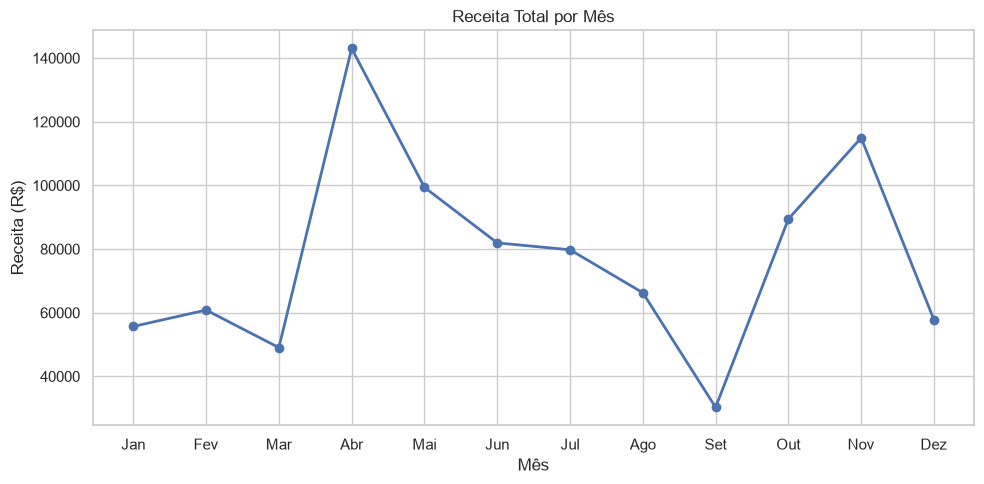

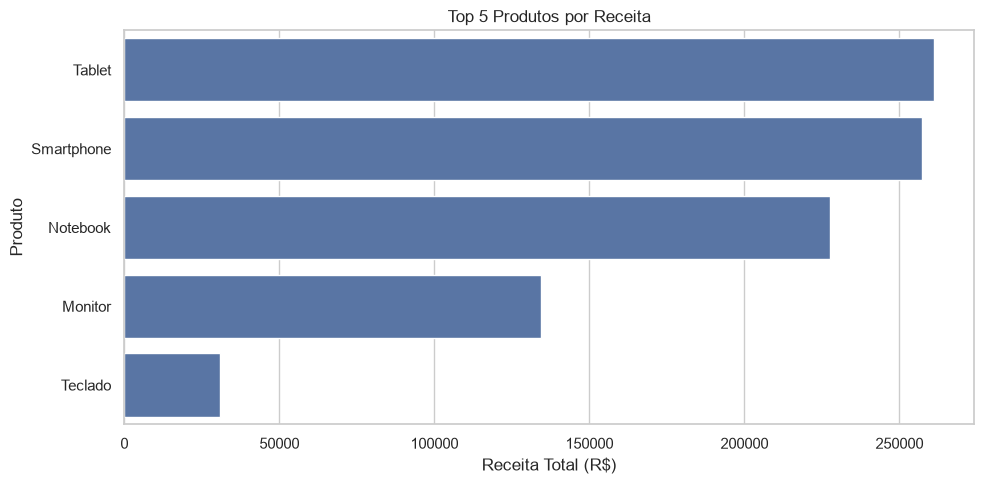

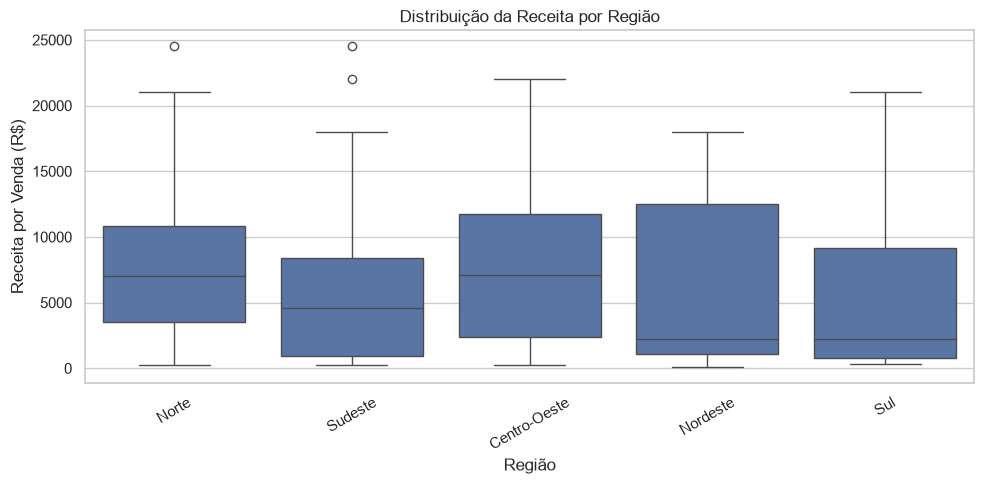


3 gráficos salvos em:
../outputs/graficos


In [42]:
gerar_visualizacoes(
    df=df_analise,
    metricas=metricas
)

RF10 – Organizar o Código em Funções Reutilizáveis

RF11 – Ler e Escrever Arquivos (CSV e JSON)

RF12 – Consolidar a Análise e Salvar o Dataset Final